# Stage 2

## Tentukan Tujuan Model dan Metrik Evaluasi
Tentukan tipe problem: klasifikasi <br>
Metrik : F1-Score, ROC-AUC karena data yang digunakan imbalanced.

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [49]:
df_general = pd.read_csv('general_data.csv')
df_employee = pd.read_csv('employee_survey_data.csv')
df_manager = pd.read_csv('manager_survey_data.csv')
df_in_time = pd.read_csv('in_time.csv')
df_out_time = pd.read_csv('out_time.csv')

In [50]:
cols_to_fix = df_in_time.columns[1:]

df_in_time[cols_to_fix] = df_in_time[cols_to_fix].apply(pd.to_datetime)
df_out_time[cols_to_fix] = df_out_time[cols_to_fix].apply(pd.to_datetime)
work_hours = df_out_time.iloc[:, 1:] - df_in_time.iloc[:, 1:]

In [51]:
work_hours = (df_out_time.iloc[:, 1:] - df_in_time.iloc[:, 1:]) / pd.Timedelta(hours=1)
total_work_hours = work_hours.sum(axis=1)
average_work_hours = work_hours.mean(axis=1)

df_in_time.iloc[:, 1:] = df_in_time.iloc[:, 1:].apply(pd.to_datetime, errors='coerce')
df_out_time.iloc[:, 1:] = df_out_time.iloc[:, 1:].apply(pd.to_datetime, errors='coerce')

in_long = df_in_time.melt(id_vars=['Unnamed: 0'],
                     var_name='date',
                     value_name='in_time')

out_long = df_out_time.melt(id_vars=['Unnamed: 0'],
                       var_name='date',
                       value_name='out_time')

df = in_long.merge(out_long, on=['Unnamed: 0', 'date'])

df = df.dropna(subset=['in_time', 'out_time'])

df['work_hours'] = (df['out_time'] - df['in_time']).dt.total_seconds() / 3600

df = df[df['work_hours'] >= 0]

df['is_overwork'] = df['work_hours'] >= 9

overwork_days = df.groupby('Unnamed: 0')['is_overwork'].sum()
overwork_days = overwork_days.reset_index(drop=True)

In [52]:
df_in_out = pd.concat(
    [total_work_hours, average_work_hours, overwork_days],
    axis=1
)

df_in_out.columns = ['total_work_hours', 'average_work_hours', 'overwork_days']
df_in_out = df_in_out.reset_index()

In [53]:
df_in_out['overwork'] = df_in_out['total_work_hours'].apply(
    lambda x: 'Yes' if x > 2080 else 'No'
)

In [54]:
df_in_out = df_in_out.drop(columns=['index'])

df_in_out.insert(0, 'EmployeeID', range(1, len(df_in_out) + 1))

In [55]:
final_df = pd.merge(df_general, df_employee, on='EmployeeID')
final_df = pd.merge(final_df,df_manager, on='EmployeeID')
final_df = pd.merge(final_df,df_in_out, on='EmployeeID')

In [56]:
final_df['Attrition'] = final_df['Attrition'].map({'Yes': 1, 'No': 0})
final_df['isMale'] = final_df['Gender'].map({'Male': 1, 'Female': 0})
final_df['overwork'] = final_df['overwork'].map({'Yes': 1, 'No': 0})

In [57]:
final_df = pd.get_dummies(final_df, columns=['Department'],dtype=int, drop_first=True)
final_df = pd.get_dummies(final_df, columns=['EducationField'],dtype=int, drop_first=True)
final_df = pd.get_dummies(final_df, columns=['JobRole'],dtype=int, drop_first=True)
final_df = pd.get_dummies(final_df, columns=['MaritalStatus'],dtype=int, drop_first=True)
final_df = pd.get_dummies(final_df, columns=['BusinessTravel'],dtype=int, drop_first=True)

## Split Dataset & Preprocessing

In [58]:
from sklearn.model_selection import train_test_split

y = final_df['Attrition']
X = final_df.drop(columns=['Attrition'])

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.4,
    random_state= 42,
    stratify=y
)

In [59]:
X_train.fillna({'EnvironmentSatisfaction':X_train['EnvironmentSatisfaction'].mode()[0]}, inplace=True)
X_train.fillna({'JobSatisfaction':X_train['JobSatisfaction'].mode()[0]}, inplace=True)
X_train.fillna({'WorkLifeBalance':X_train['WorkLifeBalance'].mode()[0]}, inplace=True)
X_train.fillna({'NumCompaniesWorked':X_train['NumCompaniesWorked'].mode()[0]}, inplace=True)
X_train.fillna({'TotalWorkingYears':X_train['TotalWorkingYears'].mode()[0]}, inplace=True)

X_val.fillna({'EnvironmentSatisfaction':X_val['EnvironmentSatisfaction'].mode()[0]}, inplace=True)
X_val.fillna({'JobSatisfaction':X_val['JobSatisfaction'].mode()[0]}, inplace=True)
X_val.fillna({'WorkLifeBalance':X_val['WorkLifeBalance'].mode()[0]}, inplace=True)
X_val.fillna({'NumCompaniesWorked':X_val['NumCompaniesWorked'].mode()[0]}, inplace=True)
X_val.fillna({'TotalWorkingYears':X_val['TotalWorkingYears'].mode()[0]}, inplace=True)

X.fillna({'EnvironmentSatisfaction':X['EnvironmentSatisfaction'].mode()[0]}, inplace=True)
X.fillna({'JobSatisfaction':X['JobSatisfaction'].mode()[0]}, inplace=True)
X.fillna({'WorkLifeBalance':X['WorkLifeBalance'].mode()[0]}, inplace=True)
X.fillna({'NumCompaniesWorked':X['NumCompaniesWorked'].mode()[0]}, inplace=True)
X.fillna({'TotalWorkingYears':X['TotalWorkingYears'].mode()[0]}, inplace=True)

In [60]:
X_train['DistanceFromHome_log'] = np.log1p(X_train['DistanceFromHome'])
X_train['MonthlyIncome_log'] = np.log1p(X_train['MonthlyIncome'])
X_train['NumCompaniesWorked_log'] = np.log1p(X_train['NumCompaniesWorked'])
X_train['PercentSalaryHike_log'] = np.log1p(X_train['PercentSalaryHike'])
X_train['TotalWorkingYears_log'] = np.log1p(X_train['TotalWorkingYears'])
X_train['YearsAtCompany_log'] = np.log1p(X_train['YearsAtCompany'])
X_train['YearsSinceLastPromotion_log'] = np.log1p(X_train['YearsSinceLastPromotion'])
X_train['YearsWithCurrManager_log'] = np.log1p(X_train['YearsWithCurrManager'])

X_val['DistanceFromHome_log'] = np.log1p(X_val['DistanceFromHome'])
X_val['MonthlyIncome_log'] = np.log1p(X_val['MonthlyIncome'])
X_val['NumCompaniesWorked_log'] = np.log1p(X_val['NumCompaniesWorked'])
X_val['PercentSalaryHike_log'] = np.log1p(X_val['PercentSalaryHike'])
X_val['TotalWorkingYears_log'] = np.log1p(X_val['TotalWorkingYears'])
X_val['YearsAtCompany_log'] = np.log1p(X_val['YearsAtCompany'])
X_val['YearsSinceLastPromotion_log'] = np.log1p(X_val['YearsSinceLastPromotion'])
X_val['YearsWithCurrManager_log'] = np.log1p(X_val['YearsWithCurrManager'])

X['DistanceFromHome_log'] = np.log1p(X['DistanceFromHome'])
X['MonthlyIncome_log'] = np.log1p(X['MonthlyIncome'])
X['NumCompaniesWorked_log'] = np.log1p(X['NumCompaniesWorked'])
X['PercentSalaryHike_log'] = np.log1p(X['PercentSalaryHike'])
X['TotalWorkingYears_log'] = np.log1p(X['TotalWorkingYears'])
X['YearsAtCompany_log'] = np.log1p(X['YearsAtCompany'])
X['YearsSinceLastPromotion_log'] = np.log1p(X['YearsSinceLastPromotion'])
X['YearsWithCurrManager_log'] = np.log1p(X['YearsWithCurrManager'])

In [61]:
X_train = X_train.drop(columns= ['EmployeeID','DistanceFromHome','Gender','MonthlyIncome','NumCompaniesWorked','PercentSalaryHike',
                                   'TotalWorkingYears','YearsAtCompany','YearsAtCompany','YearsSinceLastPromotion','YearsWithCurrManager',
                                   'TotalWorkingYears_log','YearsSinceLastPromotion_log','YearsWithCurrManager_log',
                                   'average_work_hours','overwork_days','overwork','StandardHours','EmployeeCount','Over18'])
X_val = X_val.drop(columns= ['EmployeeID','DistanceFromHome','Gender','MonthlyIncome','NumCompaniesWorked','PercentSalaryHike',
                                   'TotalWorkingYears','YearsAtCompany','YearsAtCompany','YearsSinceLastPromotion','YearsWithCurrManager',
                                   'TotalWorkingYears_log','YearsSinceLastPromotion_log','YearsWithCurrManager_log',
                                   'average_work_hours','overwork_days','overwork','StandardHours','EmployeeCount','Over18'])
X = X.drop(columns= ['EmployeeID','DistanceFromHome','Gender','MonthlyIncome','NumCompaniesWorked','PercentSalaryHike',
                                   'TotalWorkingYears','YearsAtCompany','YearsAtCompany','YearsSinceLastPromotion','YearsWithCurrManager',
                                   'TotalWorkingYears_log','YearsSinceLastPromotion_log','YearsWithCurrManager_log',
                                   'average_work_hours','overwork_days','overwork','StandardHours','EmployeeCount','Over18'])

## Modeling

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate

def eval_classification(model):
    # prediction
    y_pred = model.predict(X_val)
    y_pred_train = model.predict(X_train)

    # probability
    y_proba = model.predict_proba(X_val)[:,1]
    y_proba_train = model.predict_proba(X_train)[:,1]

    # metrics
    print("Accuracy (val Set): %.2f" % accuracy_score(y_val, y_pred))
    print("Accuracy (Train Set): %.2f" % accuracy_score(y_train, y_pred_train))
    print("Precision (val Set): %.2f" % precision_score(y_val, y_pred))
    print("Recall (val Set): %.2f" % recall_score(y_val, y_pred))
    print("F1-Score (val Set): %.2f" % f1_score(y_val, y_pred))
    print("roc_auc (val): %.2f" % roc_auc_score(y_val, y_proba))
    print("roc_auc (train): %.2f" % roc_auc_score(y_train, y_proba_train))

    score = cross_validate(model, X, y, cv=5, scoring='recall', return_train_score=True)
    print('recall (cv train):', score['train_score'].mean())
    print('recall (cv test):', score['test_score'].mean())

def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title('feature importance score')

def show_best_hyperparameter(model):
    print(model.best_estimator_.get_params())

### Logistic Regression

In [64]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_lr.fit(X_train, y_train)

y_prob = pipeline_lr.predict_proba(X_val)[:, 1]
y_pred_custom = (y_prob >= 0.5).astype(int)
roc_auc = roc_auc_score(y_val, y_pred_custom)
y_pred = pipeline_lr.predict(X_val)
print(classification_report(y_val, y_pred_custom))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1480
           1       0.62      0.24      0.35       284

    accuracy                           0.85      1764
   macro avg       0.74      0.61      0.63      1764
weighted avg       0.83      0.85      0.83      1764



In [65]:
eval_classification(pipeline_lr)

Accuracy (val Set): 0.85
Accuracy (Train Set): 0.86
Precision (val Set): 0.62
Recall (val Set): 0.24
F1-Score (val Set): 0.35
roc_auc (val): 0.79
roc_auc (train): 0.81
recall (cv train): 0.23910121537661824
recall (cv test): 0.2292524377031419


In [66]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, pipeline_lr.predict(X_val)))

[[1438   42]
 [ 216   68]]


#### Parameter Tuning

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

logreg_tuned = LogisticRegression(random_state=42, max_iter=1000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0,1],
    'solver': ['liblinear']
}

grid_search_lr = GridSearchCV(
    estimator=logreg_tuned,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# training
grid_search_lr.fit(X_train, y_train)

# prediction pakai test yang sudah di-scale
y_pred_lr = grid_search_lr.best_estimator_.predict(X_val)

print(classification_report(y_val, y_pred_lr))
print("Parameter Terbaik:",grid_search_lr.best_params_)

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1480
           1       0.63      0.25      0.36       284

    accuracy                           0.86      1764
   macro avg       0.75      0.61      0.64      1764
weighted avg       0.83      0.86      0.83      1764

Parameter Terbaik: {'C': 10, 'l1_ratio': 0, 'solver': 'liblinear'}


In [68]:
print(eval_classification(grid_search_lr))

Accuracy (val Set): 0.86
Accuracy (Train Set): 0.86
Precision (val Set): 0.63
Recall (val Set): 0.25
F1-Score (val Set): 0.36
roc_auc (val): 0.79
roc_auc (train): 0.81
recall (cv train): 0.23312334463724346
recall (cv test): 0.2348960898256673
None


In [69]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_val, grid_search_lr.predict(X_val)))

[[1439   41]
 [ 213   71]]


#### Coefficient Importance

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def show_logreg_importance(model, feature_names):

    # cek apakah model pipeline atau bukan
    if hasattr(model, 'named_steps'):
        model_fit = model.named_steps['model']
    else:
        model_fit = model

    # coefficient
    importance = model_fit.coef_[0]

    # dataframe
    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': importance,
        'Abs_Coefficient': np.abs(importance)
    })

    # sorting
    feat_imp = feat_imp.sort_values(
        by='Abs_Coefficient',
        ascending=False
    )

    # plot
    plt.figure(figsize=(10,8))
    plt.barh(feat_imp['Feature'], feat_imp['Coefficient'])
    plt.gca().invert_yaxis()

    plt.title('Logistic Regression Feature Importance')
    plt.xlabel('Coefficient')
    plt.show()

    return feat_imp

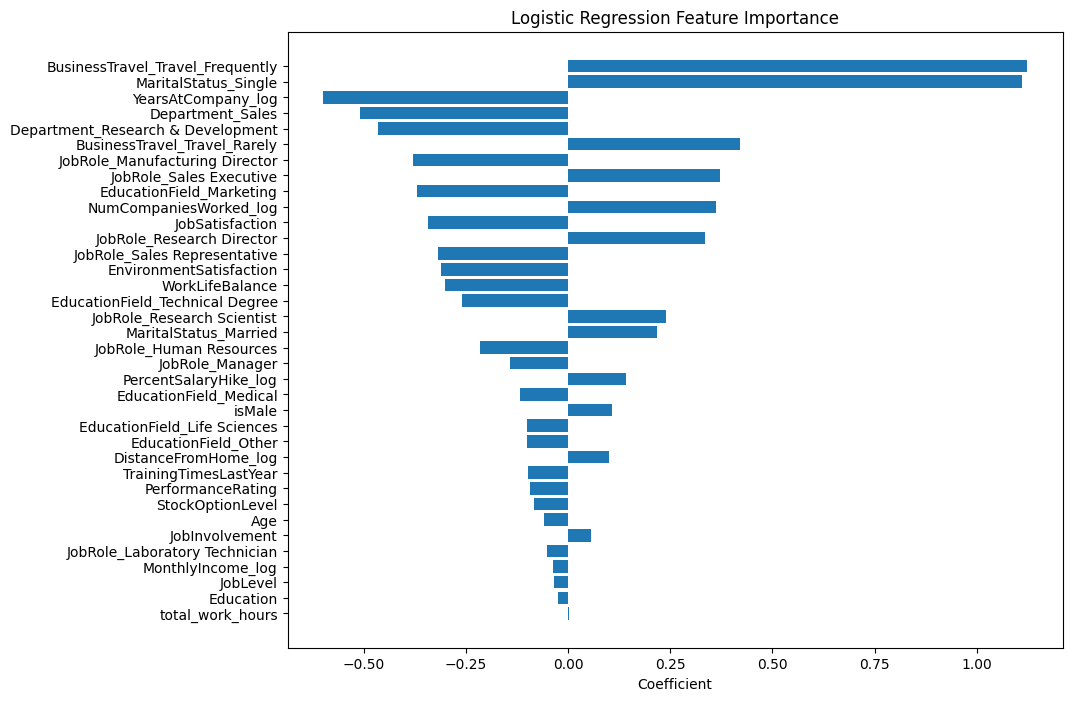

                              Feature  Coefficient  Abs_Coefficient
29   BusinessTravel_Travel_Frequently     1.124081         1.124081
28               MaritalStatus_Single     1.112062         1.112062
35                 YearsAtCompany_log    -0.600387         0.600387
13                   Department_Sales    -0.508175         0.508175
12  Department_Research & Development    -0.465874         0.465874
30       BusinessTravel_Travel_Rarely     0.420101         0.420101
22     JobRole_Manufacturing Director    -0.378603         0.378603
25            JobRole_Sales Executive     0.371630         0.371630
15           EducationField_Marketing    -0.369249         0.369249
33             NumCompaniesWorked_log     0.363121         0.363121
6                     JobSatisfaction    -0.342508         0.342508
23          JobRole_Research Director     0.336105         0.336105
26       JobRole_Sales Representative    -0.319161         0.319161
5             EnvironmentSatisfaction    -0.3100

In [71]:
logreg_importance = show_logreg_importance(
    grid_search_lr.best_estimator_,
    X_train.columns
)

print(logreg_importance)

### Decision Tree

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    #('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(
        #max_depth=5,
        #min_samples_leaf=20,
        random_state=42,
        ))
])
pipeline_dt.fit(X_train, y_train)
y_prob = pipeline_dt.predict_proba(X_val)[:, 1]
y_pred_custom = (y_prob >= 0.25).astype(int)
roc_auc = roc_auc_score(y_val, y_pred_custom)
y_pred = pipeline_dt.predict(X_val)
print(classification_report(y_val, y_pred_custom))
print("ROC AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1480
           1       0.81      0.81      0.81       284

    accuracy                           0.94      1764
   macro avg       0.89      0.89      0.89      1764
weighted avg       0.94      0.94      0.94      1764

ROC AUC: 0.8852636086791016


In [73]:
eval_classification(pipeline_dt)

Accuracy (val Set): 0.94
Accuracy (Train Set): 1.00
Precision (val Set): 0.81
Recall (val Set): 0.81
F1-Score (val Set): 0.81
roc_auc (val): 0.89
roc_auc (train): 1.00
recall (cv train): 1.0
recall (cv test): 0.9578055747069831


In [74]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, pipeline_dt.predict(X_val)))

[[1427   53]
 [  55  229]]


#### Parameter Tuning

In [75]:
from imblearn.pipeline import Pipeline
#from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

pipeline = Pipeline([
    ('model', DecisionTreeClassifier(
        #max_depth=5,
        #min_samples_leaf=20,
        random_state=42))
])

param_dist = {
    'model__max_depth': [3, 5, 7, 10],
    'model__min_samples_split': [5, 10, 20],
    'model__min_samples_leaf': [2, 5, 10],
    'model__criterion': ['gini', 'entropy']
}

random_search_dt = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

random_search_dt.fit(X_train, y_train)

y_pred = random_search_dt.predict(X_val)

print(classification_report(y_val, y_pred))
print("Parameter Terbaik:", random_search_dt.best_params_)

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      1480
           1       0.69      0.57      0.63       284

    accuracy                           0.89      1764
   macro avg       0.81      0.76      0.78      1764
weighted avg       0.88      0.89      0.89      1764

Parameter Terbaik: {'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_depth': 10, 'model__criterion': 'gini'}


In [76]:
eval_classification(random_search_dt)

Accuracy (val Set): 0.89
Accuracy (Train Set): 0.95
Precision (val Set): 0.69
Recall (val Set): 0.57
F1-Score (val Set): 0.63
roc_auc (val): 0.86
roc_auc (train): 0.98
recall (cv train): 0.8097774697393498
recall (cv test): 0.7454052989264256


In [77]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, random_search_dt.predict(X_val)))

[[1408   72]
 [ 121  163]]


#### Feature Importance

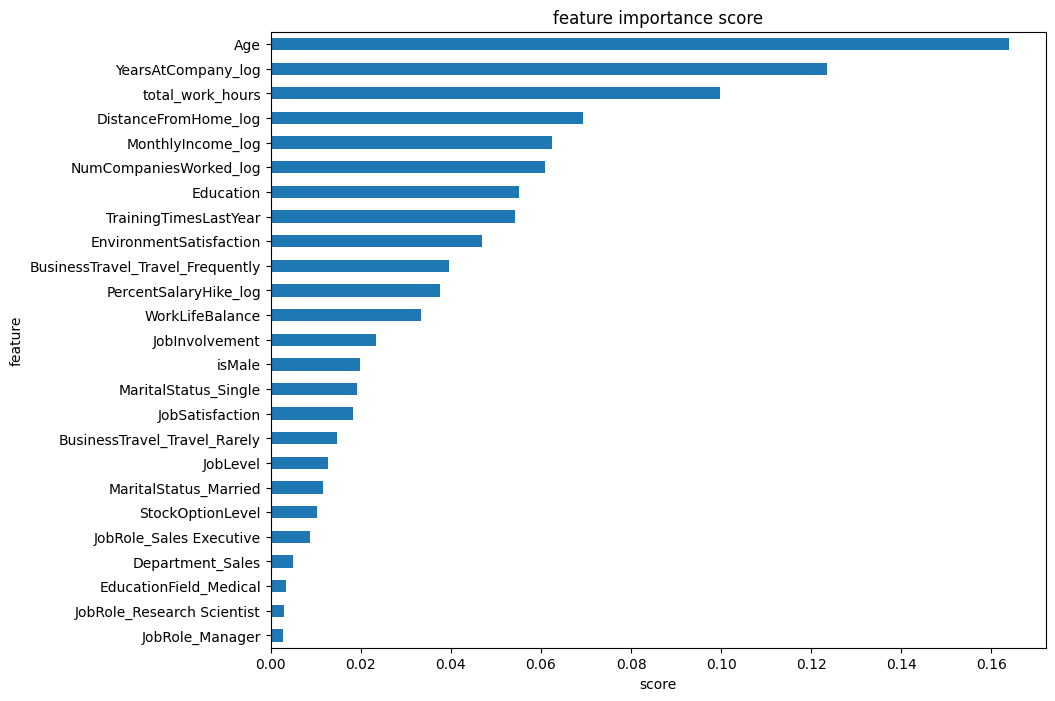

In [78]:
# ambil model decision tree dari pipeline
dt_model = random_search_dt.best_estimator_.named_steps['model']

# tampilkan feature importance
show_feature_importance(dt_model)

#### SHAP

PermutationExplainer explainer: 1765it [00:27, 40.73it/s]


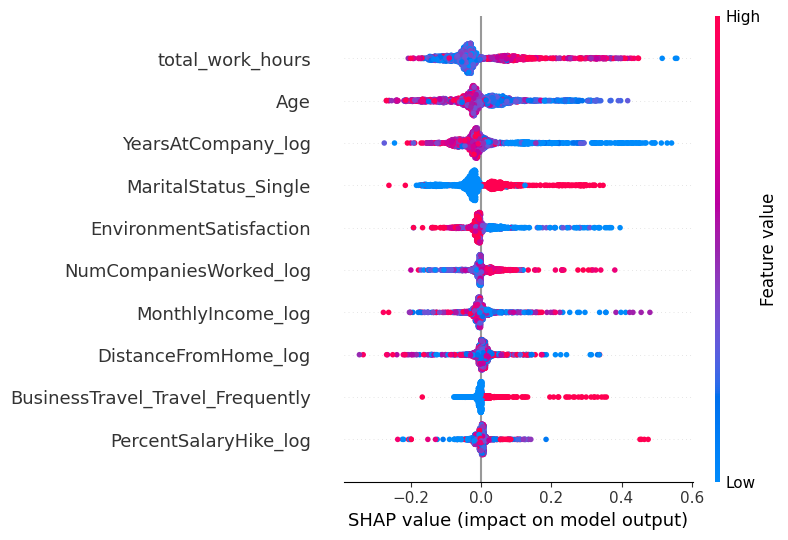

In [79]:
import shap

# ambil pipeline terbaik
dt_model = random_search_dt.best_estimator_

# explainer
explainer = shap.Explainer(
    dt_model.predict,
    X_val
)

# shap values
shap_values = explainer(X_val)

# summary plot
shap.summary_plot(
    shap_values,
    X_val,
    max_display=10
)

### RANDOM FOREST

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    #('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        random_state=42,
        #class_weight='balanced',
        #max_depth=10,
        #min_samples_leaf=5,
        #n_estimators=100
    ))
])

pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1480
           1       0.99      0.82      0.89       284

    accuracy                           0.97      1764
   macro avg       0.98      0.91      0.94      1764
weighted avg       0.97      0.97      0.97      1764



In [81]:
eval_classification(pipeline_rf)

Accuracy (val Set): 0.97
Accuracy (Train Set): 1.00
Precision (val Set): 0.99
Recall (val Set): 0.82
F1-Score (val Set): 0.89
roc_auc (val): 0.97
roc_auc (train): 1.00
recall (cv train): 1.0
recall (cv test): 0.9943858957943466


In [82]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, pipeline_rf.predict(X_val)))

[[1477    3]
 [  52  232]]


#### Parameter Tuning

In [83]:
from imblearn.pipeline import Pipeline
#from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# pipeline
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'))
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 2, 5]
}

# grid search
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

# prediksi
y_pred_rf = grid_search_rf.predict(X_val)

print(classification_report(y_val, y_pred_rf))
print("Parameter Terbaik:", grid_search_rf.best_params_)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1480
           1       0.98      0.82      0.89       284

    accuracy                           0.97      1764
   macro avg       0.97      0.91      0.94      1764
weighted avg       0.97      0.97      0.97      1764

Parameter Terbaik: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}


In [84]:
eval_classification(grid_search_rf)

Accuracy (val Set): 0.97
Accuracy (Train Set): 1.00
Precision (val Set): 0.98
Recall (val Set): 0.82
F1-Score (val Set): 0.89
roc_auc (val): 0.97
roc_auc (train): 1.00
recall (cv train): 1.0
recall (cv test): 0.9957844971929479


In [85]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_val, grid_search_rf.predict(X_val)))

[[1475    5]
 [  51  233]]


#### Feature Importance

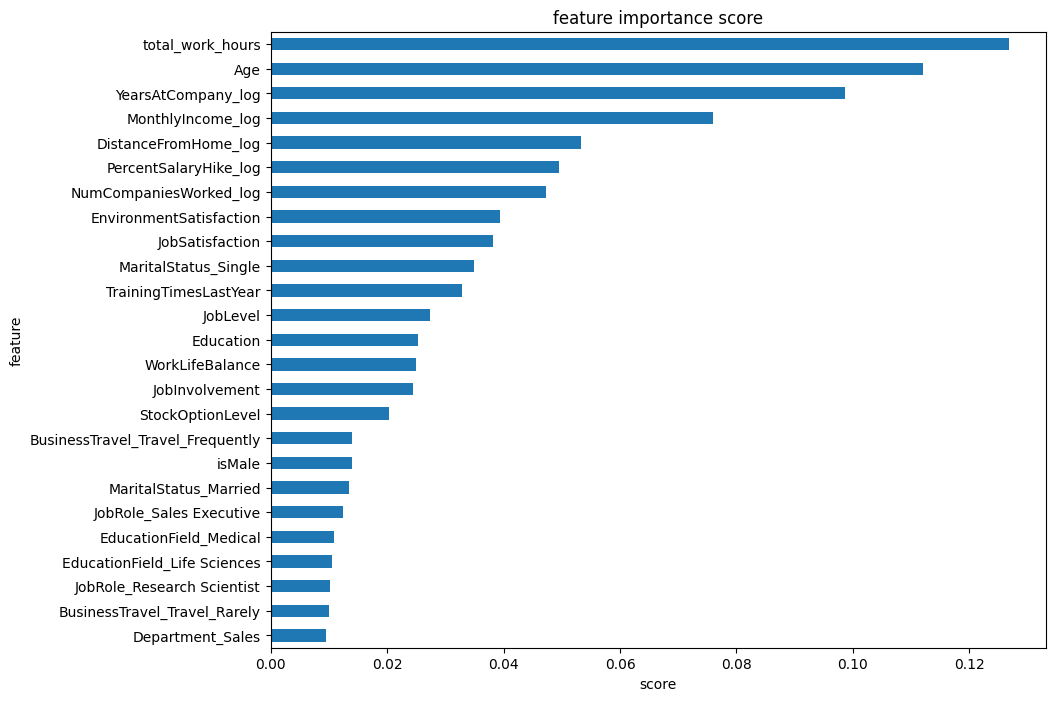

In [86]:
# ambil model decision tree dari pipeline
rf_model = grid_search_rf.best_estimator_.named_steps['model']

# tampilkan feature importance
show_feature_importance(rf_model)

#### SHAP

PermutationExplainer explainer: 1765it [09:42,  2.98it/s]


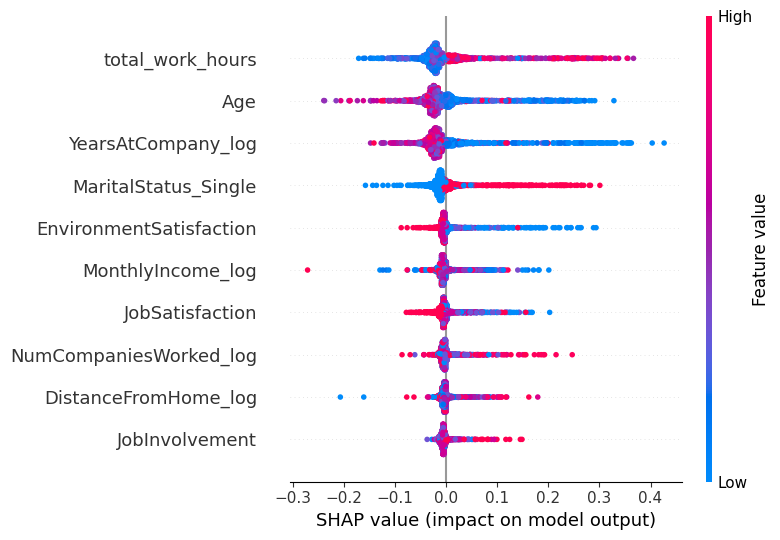

In [87]:
import shap

# ambil pipeline terbaik
rf_model = grid_search_rf.best_estimator_

# explainer
explainer = shap.Explainer(
    rf_model.predict,
    X_val
)

# shap values
shap_values = explainer(X_val)

# summary plot
shap.summary_plot(
    shap_values,
    X_val,
    max_display=10
)

### XGBOOST

In [88]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# pipeline
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(random_state=42))])

pipeline_xgb.fit(X_train, y_train)
y_pred = pipeline_xgb.predict(X_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1480
           1       0.96      0.85      0.90       284

    accuracy                           0.97      1764
   macro avg       0.97      0.92      0.94      1764
weighted avg       0.97      0.97      0.97      1764



In [89]:
eval_classification(pipeline_xgb)

Accuracy (val Set): 0.97
Accuracy (Train Set): 1.00
Precision (val Set): 0.96
Recall (val Set): 0.85
F1-Score (val Set): 0.90
roc_auc (val): 0.95
roc_auc (train): 1.00
recall (cv train): 1.0
recall (cv test): 0.9943858957943463


In [90]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, pipeline_xgb.predict(X_val)))

[[1470   10]
 [  42  242]]


#### Parameter Tuning

In [91]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

# pipeline
pipeline_xg = Pipeline([
    ('scaler', StandardScaler()),
    #('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

# hyperparameter (pakai prefix model__)
param_dist_xg = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__gamma': [0, 0.1, 0.2, 0.3],
    'model__min_child_weight': [1, 3, 5]
}

# randomized search
random_search_xg = RandomizedSearchCV(
    estimator=pipeline_xg,
    param_distributions=param_dist_xg,
    n_iter=25,
    cv=5,
    scoring='f1',  # bisa diganti recall kalau fokus attrition
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# training (pakai data asli!)
random_search_xg.fit(X_train, y_train)

# prediksi
y_pred_xg = random_search_xg.predict(X_val)

# evaluasi
print(classification_report(y_val, y_pred_xg))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1480
           1       0.95      0.85      0.89       284

    accuracy                           0.97      1764
   macro avg       0.96      0.92      0.94      1764
weighted avg       0.97      0.97      0.97      1764



In [92]:
eval_classification(random_search_xg)

Accuracy (val Set): 0.97
Accuracy (Train Set): 1.00
Precision (val Set): 0.95
Recall (val Set): 0.85
F1-Score (val Set): 0.89
roc_auc (val): 0.95
roc_auc (train): 1.00
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
recall (cv train): 1.0
recall (cv test): 0.9859351915689943


In [93]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, random_search_xg.predict(X_val)))

[[1467   13]
 [  44  240]]


#### Feature Importance

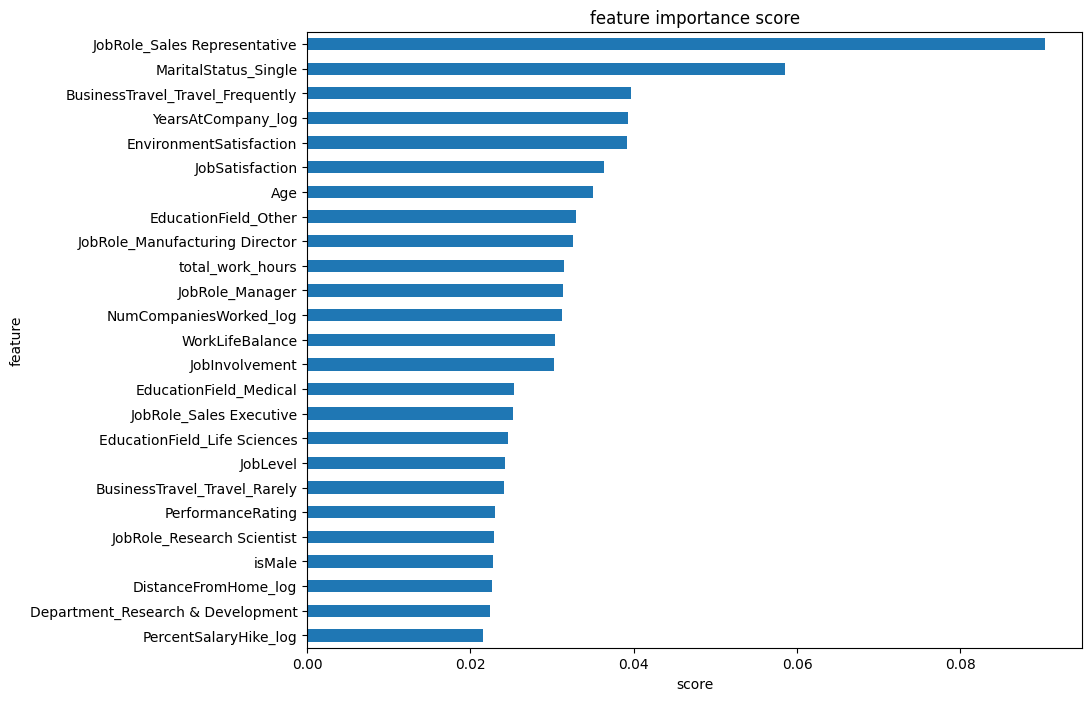

In [94]:
# ambil model decision tree dari pipeline
xg_model = random_search_xg.best_estimator_.named_steps['model']

# tampilkan feature importance
show_feature_importance(xg_model)

#### SHAP

PermutationExplainer explainer: 1765it [05:15,  5.39it/s]


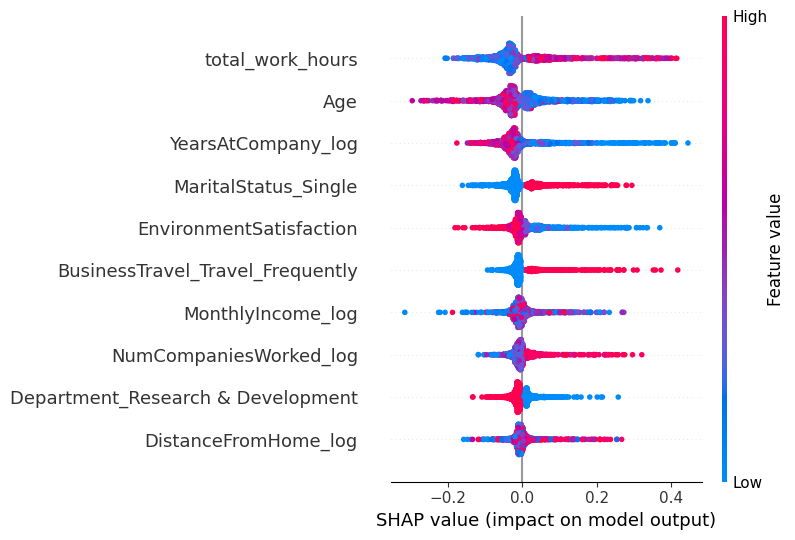

In [95]:
import shap

# ambil pipeline terbaik
xg_model = random_search_xg.best_estimator_

# explainer
explainer = shap.Explainer(
    xg_model.predict,
    X_val
)

# shap values
shap_values = explainer(X_val)

# summary plot
shap.summary_plot(
    shap_values,
    X_val,
    max_display=10
)

### LightGBM

In [96]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# pipeline
pipeline_lgbm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(random_state=42))
])

# train model
pipeline_lgbm.fit(X_train, y_train)

# prediction
y_pred = pipeline_lgbm.predict(X_val)

# evaluation
print(classification_report(y_val, y_pred))

[LightGBM] [Info] Number of positive: 427, number of negative: 2219
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 754
[LightGBM] [Info] Number of data points in the train set: 2646, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161376 -> initscore=-1.648028
[LightGBM] [Info] Start training from score -1.648028
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1480
           1       0.95      0.81      0.87       284

    accuracy                           0.96      1764
   macro avg       0.96      0.90      0.93      1764
weighted avg       0.96      0.96      0.96      1764



In [97]:
eval_classification(pipeline_lgbm)

Accuracy (val Set): 0.96
Accuracy (Train Set): 1.00
Precision (val Set): 0.95
Recall (val Set): 0.81
F1-Score (val Set): 0.87
roc_auc (val): 0.95
roc_auc (train): 1.00
[LightGBM] [Info] Number of positive: 569, number of negative: 2959
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 755
[LightGBM] [Info] Number of data points in the train set: 3528, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161281 -> initscore=-1.648726
[LightGBM] [Info] Start training from score -1.648726
[LightGBM] [Info] Number of positive: 569, number of negative: 2959
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_c

In [98]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, pipeline_lgbm.predict(X_val)))

[[1467   13]
 [  54  230]]


#### Parameter Tuning

In [99]:
pipeline_lgbm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(random_state=42))
])

# hyperparameter
param_lgbm = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 10, -1],
    'model__num_leaves': [20, 31, 50, 70],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_samples': [10, 20, 30]
}

# randomized search
search_lgbm = RandomizedSearchCV(
    estimator=pipeline_lgbm,
    param_distributions=param_lgbm,
    n_iter=20,
    scoring='recall',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# training hyperparameter tuning
search_lgbm.fit(X_train, y_train)

# best model
best_lgbm = search_lgbm.best_estimator_

# prediction
y_pred = best_lgbm.predict(X_val)

# evaluation
print("Best Parameters:")
print(search_lgbm.best_params_)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 427, number of negative: 2219
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 754
[LightGBM] [Info] Number of data points in the train set: 2646, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161376 -> initscore=-1.648028
[LightGBM] [Info] Start training from score -1.648028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

In [100]:
eval_classification(search_lgbm)

Accuracy (val Set): 0.97
Accuracy (Train Set): 1.00
Precision (val Set): 0.98
Recall (val Set): 0.85
F1-Score (val Set): 0.91
roc_auc (val): 0.95
roc_auc (train): 1.00
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 569, number of negative: 2959
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 755
[LightGBM] [Info] Number of data points in the train set: 3528, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161281 -> initscore=-1.648726
[LightGBM] [Info] Start training from score -1.648726
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [101]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_val, search_lgbm.predict(X_val)))

[[1474    6]
 [  43  241]]


#### Feature Importance

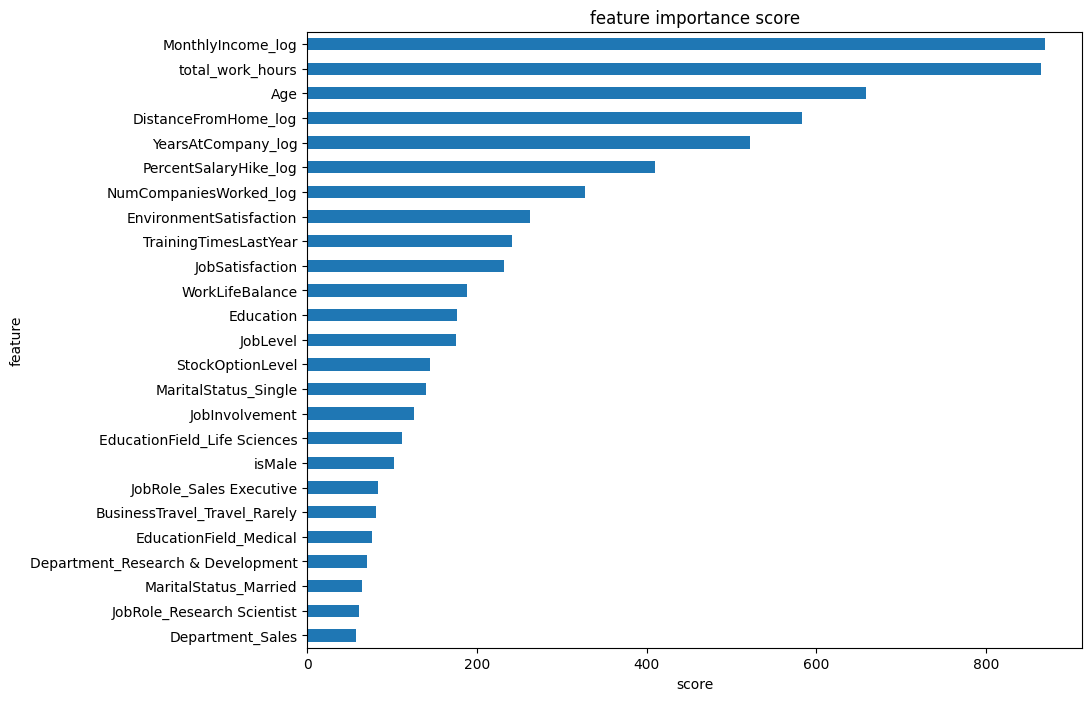

In [102]:
# ambil model decision tree dari pipeline
lgbm_model = search_lgbm.best_estimator_.named_steps['model']

# tampilkan feature importance
show_feature_importance(lgbm_model)

#### SHAP

PermutationExplainer explainer: 1765it [09:43,  2.97it/s]


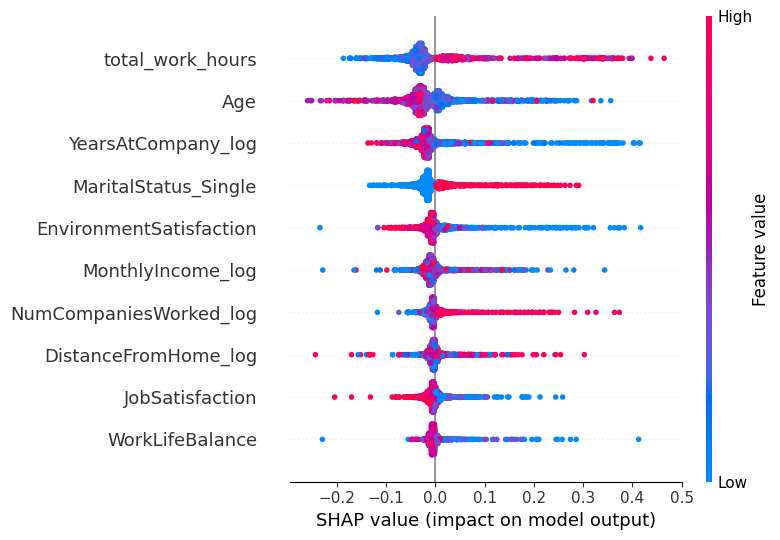

In [103]:
import shap

# ambil pipeline terbaik
lgbm_model = search_lgbm.best_estimator_

# explainer
explainer = shap.Explainer(
    lgbm_model.predict,
    X_val
)

# shap values
shap_values = explainer(X_val)

# summary plot
shap.summary_plot(
    shap_values,
    X_val,
    max_display=10
)

### CatBoost

In [104]:
!pip install catboost

In [105]:
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# pipeline
pipeline_catboost = Pipeline([
    ('scaler', StandardScaler()),
    ('model', CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

# train model
pipeline_catboost.fit(X_train, y_train)

# prediction
y_pred = pipeline_catboost.predict(X_val)

# evaluation
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1480
           1       0.97      0.77      0.86       284

    accuracy                           0.96      1764
   macro avg       0.97      0.88      0.92      1764
weighted avg       0.96      0.96      0.96      1764



In [106]:
eval_classification(pipeline_catboost)

Accuracy (val Set): 0.96
Accuracy (Train Set): 1.00
Precision (val Set): 0.97
Recall (val Set): 0.77
F1-Score (val Set): 0.86
roc_auc (val): 0.96
roc_auc (train): 1.00
recall (cv train): 0.9799574246887299
recall (cv test): 0.9507830197971042


In [107]:
print(confusion_matrix(y_val, pipeline_catboost.predict(X_val)))

[[1474    6]
 [  65  219]]


#### Parameter Tuning

In [108]:
# pipeline
pipeline_catboost = Pipeline([
    ('scaler', StandardScaler()),
    ('model', CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

# hyperparameter tuning
param_catboost = {
    'model__iterations': [100, 200, 300, 500],
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__border_count': [32, 64, 128, 255],
    'model__bagging_temperature': [0, 1, 3, 5],
    'model__random_strength': [1, 2, 5, 10]
}

# randomized search
search_catboost = RandomizedSearchCV(
    estimator=pipeline_catboost,
    param_distributions=param_catboost,
    n_iter=20,
    scoring='recall',   # focus on increasing recall
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# training
search_catboost.fit(X_train, y_train)

# best model
best_catboost = search_catboost.best_estimator_

# prediction
y_pred = best_catboost.predict(X_val)

# evaluation
print("Best Parameters:")
print(search_catboost.best_params_)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'model__random_strength': 5, 'model__learning_rate': 0.2, 'model__l2_leaf_reg': 3, 'model__iterations': 500, 'model__depth': 4, 'model__border_count': 32, 'model__bagging_temperature': 1}

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1480
           1       0.96      0.85      0.90       284

    accuracy                           0.97      1764
   macro avg       0.97      0.92      0.94      1764
weighted avg       0.97      0.97      0.97      1764



In [109]:
eval_classification(search_catboost)

Accuracy (val Set): 0.97
Accuracy (Train Set): 1.00
Precision (val Set): 0.96
Recall (val Set): 0.85
F1-Score (val Set): 0.90
roc_auc (val): 0.95
roc_auc (train): 1.00
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
recall (cv train): 1.0
recall (cv test): 0.9985915492957746


In [110]:
print(confusion_matrix(y_val, search_catboost.predict(X_val)))

[[1470   10]
 [  42  242]]


#### Feature Importance

In [111]:
# ambil model decision tree dari pipeline
cat_model = search_catboost.best_estimator_.named_steps['model']

# tampilkan feature importance
show_feature_importance(cat_model,limit=5)

TypeError: show_feature_importance() got an unexpected keyword argument 'limit'

#### SHAP

In [ ]:
import shap

# ambil pipeline terbaik
cat_model = search_catboost.best_estimator_

# explainer
explainer = shap.Explainer(
    cat_model.predict,
    X_val
)

# shap values
shap_values = explainer(X_val)

# summary plot
shap.summary_plot(
    shap_values,
    X_val,
    max_display=10
)

### AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# pipeline
pipeline_adaboost = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostClassifier(
        random_state=42
    ))
])

# train model
pipeline_adaboost.fit(X_train, y_train)

# prediction
y_pred = pipeline_adaboost.predict(X_val)

# evaluation
print(classification_report(y_val, y_pred))

In [ ]:
eval_classification(pipeline_adaboost)

In [ ]:
print(confusion_matrix(y_val, pipeline_adaboost.predict(X_val)))

#### Parameter Tuning

In [ ]:
# pipeline
pipeline_adaboost = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostClassifier(
        random_state=42
    ))
])

# hyperparameter tuning
param_adaboost = {
    'model__n_estimators': [50, 100, 200, 300, 500],
    'model__learning_rate': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    }

# randomized search
search_adaboost = RandomizedSearchCV(
    estimator=pipeline_adaboost,
    param_distributions=param_adaboost,
    n_iter=20,
    scoring='recall',   # focus on increasing recall
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# training hyperparameter tuning
search_adaboost.fit(X_train, y_train)

# best model
best_adaboost = search_adaboost.best_estimator_

# prediction
y_pred = best_adaboost.predict(X_val)

# evaluation
print("Best Parameters:")
print(search_adaboost.best_params_)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

In [ ]:
eval_classification(search_adaboost)

In [ ]:
print(confusion_matrix(y_val, search_adaboost.predict(X_val)))

#### Feature Importance

In [ ]:
# ambil model decision tree dari pipeline
ada_model = search_adaboost.best_estimator_.named_steps['model']

# tampilkan feature importance
show_feature_importance(ada_model)

#### SHAP

In [ ]:
# ambil pipeline terbaik
ada_model = search_adaboost.best_estimator_

# explainer
explainer = shap.Explainer(
    ada_model.predict,
    X_val
)

# shap values
shap_values = explainer(X_val)

# summary plot
shap.summary_plot(
    shap_values,
    X_val,
    max_display=10
)

### Multi-Layer Perceptron (MLP)

In [ ]:
from sklearn.neural_network import MLPClassifier

# pipeline
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        random_state=42,
        max_iter=500
    ))
])

# train model
pipeline_mlp.fit(X_train, y_train)

# prediction
y_pred = pipeline_mlp.predict(X_val)

# evaluation
print(classification_report(y_val, y_pred))

In [ ]:
eval_classification(pipeline_mlp)

In [ ]:
print(confusion_matrix(y_val, pipeline_mlp.predict(X_val)))

#### Parameter Tuning

In [ ]:
# pipeline
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        random_state=42,
        max_iter=1000
    ))
])

# hyperparameter tuning
param_mlp = {
    'model__hidden_layer_sizes': [
        (50,),
        (100,),
        (50,50),
        (100,50),
        (100,100)
    ],
    'model__activation': ['relu', 'tanh'],
    'model__solver': ['adam'],
    'model__alpha': [0.0001, 0.001, 0.01, 0.1],
    'model__learning_rate_init': [0.001, 0.01, 0.05],
    'model__batch_size': [32, 64, 128]
}

# randomized search
search_mlp = RandomizedSearchCV(
    estimator=pipeline_mlp,
    param_distributions=param_mlp,
    n_iter=20,
    scoring='recall',   # focus on recall
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# training hyperparameter tuning
search_mlp.fit(X_train, y_train)

# best model
best_mlp = search_mlp.best_estimator_

# prediction
y_pred = best_mlp.predict(X_val)

# evaluation
print("Best Parameters:")
print(search_mlp.best_params_)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

In [ ]:
eval_classification(search_mlp)

In [ ]:
print(confusion_matrix(y_val, search_mlp.predict(X_val)))

#### SHAP

In [ ]:
import shap

# ambil pipeline terbaik
mlp_model = search_mlp.best_estimator_

# explainer
explainer = shap.Explainer(
    mlp_model.predict,
    X_val
)

# shap values
shap_values = explainer(X_val)

# summary plot
shap.summary_plot(
    shap_values,
    X_val,
    max_display=10
)

### Tabel Evaluasi

In [ ]:
pipeline_lr.fit(X_train, y_train)
pipeline_dt.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_xgb.fit(X_train, y_train)
pipeline_lgbm.fit(X_train, y_train)
pipeline_catboost.fit(X_train, y_train)
pipeline_adaboost.fit(X_train, y_train)
pipeline_mlp.fit(X_train, y_train)

In [ ]:
for name, model in models_baseline.items():
    try:
        model.predict(X_val)
        print(f"{name} sudah fit")

    except Exception as e:
        print(f"{name} ERROR:")
        print(e)
        print("-"*50)

In [ ]:
import pandas as pd
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# kumpulan model sebelum hyperparameter tuning
models_baseline = {
    'Logistic Regression': pipeline_lr,
    'Decision Tree': pipeline_dt,
    'Random Forest': pipeline_rf,
    'XGBoost': pipeline_xgb,
    'LightGBM': pipeline_lgbm,
    'CatBoost': pipeline_catboost,
    'AdaBoost': pipeline_adaboost,
    'ANN (MLP)': pipeline_mlp
}

# list hasil evaluasi
results_baseline = []

# evaluasi setiap model
for name, model in models_baseline.items():

    # prediction
    y_pred = model.predict(X_val)

    # probability prediction
    y_proba = model.predict_proba(X_val)[:, 1]

    # metrics
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)

    # simpan hasil
    results_baseline.append({
        'Model': name,
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

# dataframe
results_baseline_df = pd.DataFrame(results_baseline)

# sorting berdasarkan recall
results_baseline_df = results_baseline_df.sort_values(
    by='Recall',
    ascending=False
)

# reset index
results_baseline_df = results_baseline_df.reset_index(drop=True)

# tampilkan hasil
print(results_baseline_df)

In [ ]:
import pandas as pd
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# kumpulan model terbaik hasil hyperparameter tuning
models = {
    'Logistic Regression': grid_search_lr.best_estimator_,
    'Decision Tree': random_search_dt.best_estimator_,
    'Random Forest': grid_search_rf.best_estimator_,
    'XGBoost': random_search_xg.best_estimator_,
    'LightGBM': search_lgbm.best_estimator_,
    'CatBoost': search_catboost.best_estimator_,
    'AdaBoost': search_adaboost.best_estimator_,
    'ANN (MLP)': search_mlp.best_estimator_
}

# list hasil evaluasi
results = []

# looping evaluasi setiap model
for name, model in models.items():

    # prediction
    y_pred = model.predict(X_val)

    # probability prediction untuk ROC-AUC
    y_proba = model.predict_proba(X_val)[:, 1]

    # hitung metric
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)

    # simpan hasil
    results.append({
        'Model': name,
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

# dataframe hasil evaluasi
results_df = pd.DataFrame(results)

# sorting berdasarkan recall tertinggi
results_df = results_df.sort_values(by='Recall', ascending=False)

# reset index
results_df = results_df.reset_index(drop=True)

# tampilkan tabel
print(results_df)